In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/quora-question-pairs/train.csv.zip
/kaggle/input/competitions/quora-question-pairs/sample_submission.csv.zip
/kaggle/input/competitions/quora-question-pairs/test.csv
/kaggle/input/competitions/quora-question-pairs/test.csv.zip


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [57]:
df=pd.read_csv("/kaggle/input/competitions/quora-question-pairs/train.csv.zip")

In [58]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [59]:
df.shape

(404290, 6)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [61]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
55517,55517,74898,97868,How realistic would it be to lose 40 pounds in...,Are there any complications if you lose 40 pou...,0
25313,25313,47194,47195,How can I commit suicide without any pain?,What is the easiest way to kill yourself witho...,1
141345,141345,224409,224410,What was the saddest moment of your life?,What's the saddest moment of your life?,1
52644,52644,93182,93183,How many numbers between 100 and 500 are divis...,How many numbers between 100 and 300 are divis...,0
38819,38819,70454,70455,How do you write the letter 'x'?,How can I write a letter?,0


In [62]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [65]:
(df['is_duplicate'].value_counts())/(df['is_duplicate'].count()) *100

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64

<Axes: xlabel='is_duplicate'>

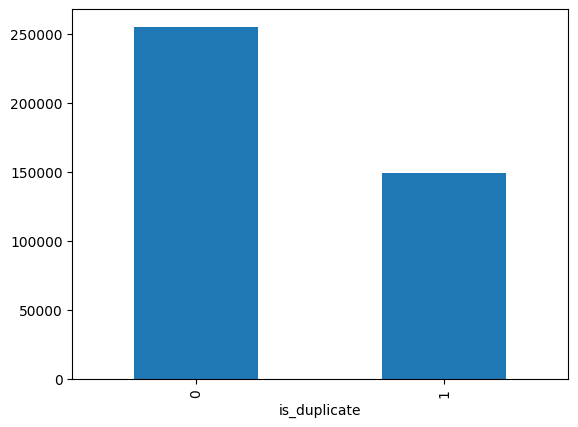

In [66]:
df['is_duplicate'].value_counts().plot(kind="bar")

In [67]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print("Number of unique questions:",np.unique(qid).shape[0])
x=qid.value_counts()>1
print("number of duplicated questions",x[x].shape[0])

Number of unique questions: 537933
number of duplicated questions 111780


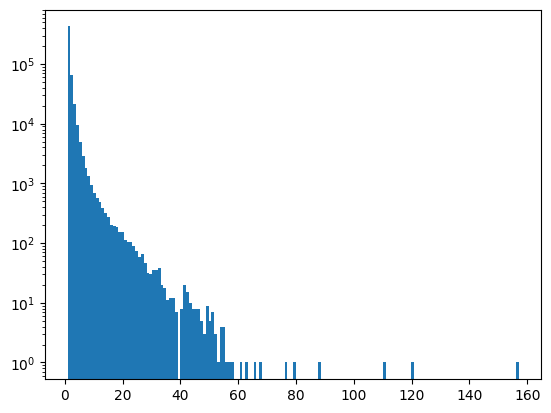

In [68]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')

# Simplest Approach

In [69]:
new_df=df.sample(30000)

In [70]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [71]:
new_df.duplicated().sum()

np.int64(0)

In [72]:
ques_df=new_df[['question1','question2']]

In [73]:
ques_df.head()

,question1,question2
351592,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?
308390,How would I treat a miss using meth?,How do I get erect while using meth?
23617,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?
301696,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...
214651,Does being more than two years out of college ...,I am a graduated student in a master of financ...


In [74]:
from sklearn.feature_extraction.text import CountVectorizer

questions=(ques_df['question1']).tolist()+(ques_df['question2']).tolist()
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [75]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [76]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
351592,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
308390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23617,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
301696,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
214651,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [78]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
351592,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
308390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23617,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
301696,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
214651,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [80]:
X_train.shape,X_test.shape

((24000, 6000), (6000, 6000))

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7353333333333333

In [82]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.722

# Feature extraction

In [83]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()

In [84]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
351592,351592,103586,480446,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?,0,50,46
308390,308390,125877,241157,How would I treat a miss using meth?,How do I get erect while using meth?,0,36,36
23617,23617,44220,44221,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?,1,39,44
301696,301696,191923,424627,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...,0,87,88
214651,214651,320298,320299,Does being more than two years out of college ...,I am a graduated student in a master of financ...,0,148,254


In [85]:
new_df['q1_num_wwords']=new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_wwords']=new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords
351592,351592,103586,480446,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?,0,50,46,7,9
308390,308390,125877,241157,How would I treat a miss using meth?,How do I get erect while using meth?,0,36,36,8,8
23617,23617,44220,44221,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?,1,39,44,9,9
301696,301696,191923,424627,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...,0,87,88,16,18
214651,214651,320298,320299,Does being more than two years out of college ...,I am a graduated student in a master of financ...,0,148,254,23,52


In [86]:
def common_words(row):
    w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [87]:
new_df['word_common']=new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common
351592,351592,103586,480446,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?,0,50,46,7,9,4
308390,308390,125877,241157,How would I treat a miss using meth?,How do I get erect while using meth?,0,36,36,8,8,4
23617,23617,44220,44221,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?,1,39,44,9,9,7
301696,301696,191923,424627,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...,0,87,88,16,18,3
214651,214651,320298,320299,Does being more than two years out of college ...,I am a graduated student in a master of financ...,0,148,254,23,52,7


In [88]:
def total_words(row):
    w1=set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [89]:
new_df['total_words']=new_df.apply(total_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words
351592,351592,103586,480446,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?,0,50,46,7,9,4,16
308390,308390,125877,241157,How would I treat a miss using meth?,How do I get erect while using meth?,0,36,36,8,8,4,16
23617,23617,44220,44221,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?,1,39,44,9,9,7,18
301696,301696,191923,424627,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...,0,87,88,16,18,3,31
214651,214651,320298,320299,Does being more than two years out of college ...,I am a graduated student in a master of financ...,0,148,254,23,52,7,62


In [90]:
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
351592,351592,103586,480446,What is the eccentricity of rectangular hyperb...,How do I find the eccentricity of a hyperbola?,0,50,46,7,9,4,16,0.25
308390,308390,125877,241157,How would I treat a miss using meth?,How do I get erect while using meth?,0,36,36,8,8,4,16,0.25
23617,23617,44220,44221,How do I prepare for CAT 2017 from now?,How do I prepare for CAT 2017 (BBA student)?,1,39,44,9,9,7,18,0.39
301696,301696,191923,424627,Has anyone been able to get into US after thei...,I've been denied an F1 visa. How do I return t...,0,87,88,16,18,3,31,0.10
214651,214651,320298,320299,Does being more than two years out of college ...,I am a graduated student in a master of financ...,0,148,254,23,52,7,62,0.11


# Analysis in new features

minimum characters: 1
maximum characters: 335
Average no of  characters: 59


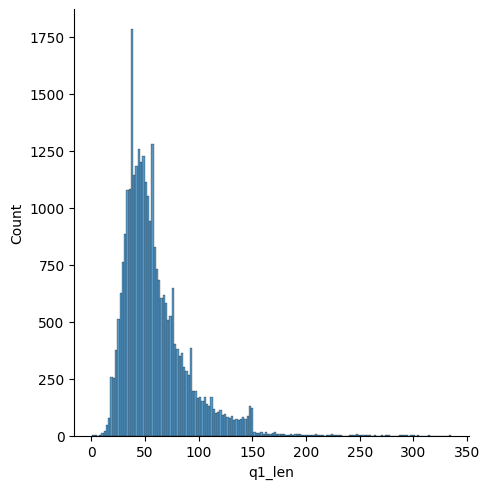

In [91]:
sns.displot(new_df['q1_len'])
print("minimum characters:",new_df['q1_len'].min())
print("maximum characters:",new_df['q1_len'].max())
print("Average no of  characters:",int(new_df['q1_len'].mean()))

minimum characters: 5
maximum characters: 589
Average no of  characters: 59


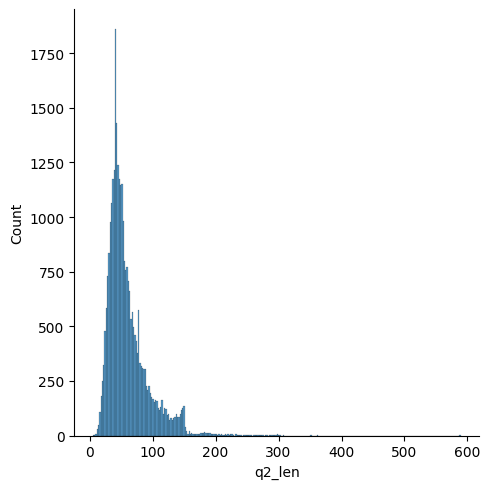

In [92]:
sns.displot(new_df['q2_len'])
print("minimum characters:",new_df['q2_len'].min())
print("maximum characters:",new_df['q2_len'].max())
print("Average no of  characters:",int(new_df['q2_len'].mean()))

minimum characters: 1
maximum characters: 73
Average no of  characters: 10


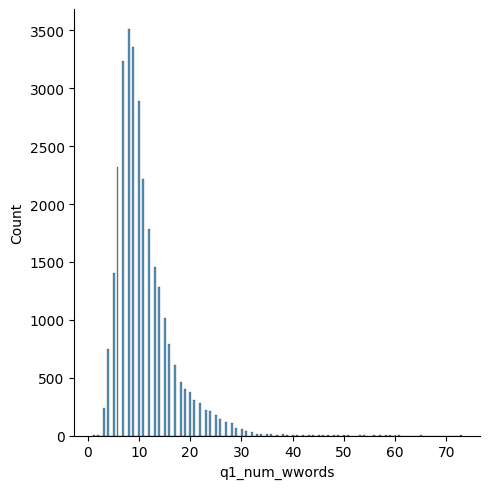

In [93]:
sns.displot(new_df['q1_num_wwords'])
print("minimum characters:",new_df['q1_num_wwords'].min())
print("maximum characters:",new_df['q1_num_wwords'].max())
print("Average no of  characters:",int(new_df['q1_num_wwords'].mean()))

minimum characters: 1
maximum characters: 112
Average no of  characters: 11


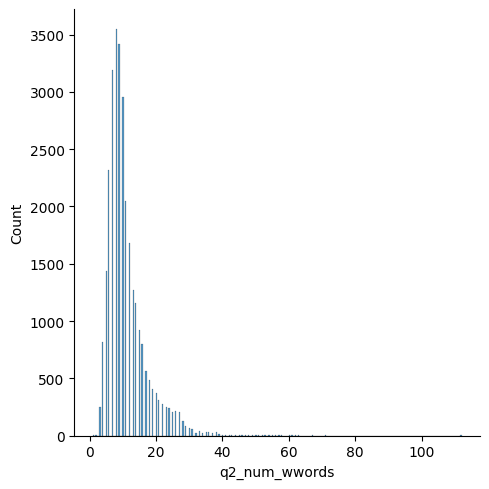

In [94]:
sns.displot(new_df['q2_num_wwords'])
print("minimum characters:",new_df['q2_num_wwords'].min())
print("maximum characters:",new_df['q2_num_wwords'].max())
print("Average no of  characters:",int(new_df['q2_num_wwords'].mean()))

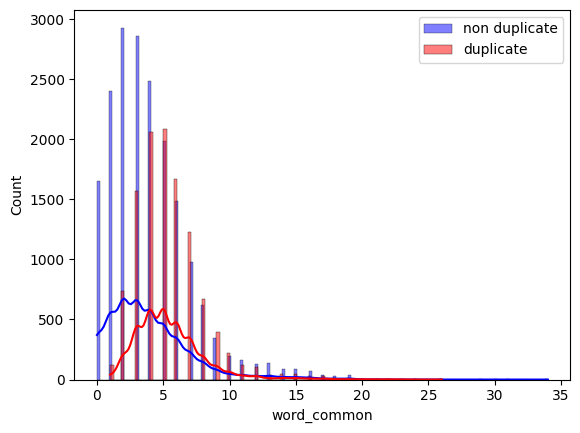

In [95]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['word_common'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['word_common'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

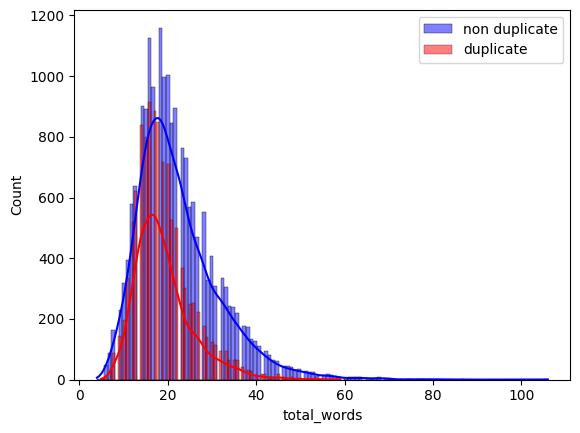

In [96]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['total_words'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['total_words'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

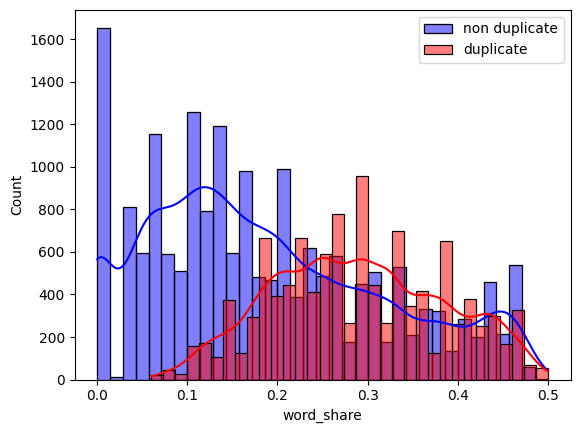

In [97]:
# Use histplot instead of displot to draw them on the same axes
sns.histplot(new_df[new_df['is_duplicate']==0]['word_share'], color='blue', label='non duplicate', kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['word_share'], color='red', label='duplicate', kde=True)

# Now the legend will show both colors correctly
plt.legend()
plt.show()

# Making New Data

In [98]:
final_df=new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share
351592,0,50,46,7,9,4,16,0.25
308390,0,36,36,8,8,4,16,0.25
23617,1,39,44,9,9,7,18,0.39
301696,0,87,88,16,18,3,31,0.10
214651,0,148,254,23,52,7,62,0.11


In [99]:
temp_df=temp_df.drop(columns=['is_duplicate'])

In [100]:
final_df=pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_wwords,q2_num_wwords,word_common,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
351592,0,50,46,7,9,4,16,0.25,0,0,...,0,0,0,0,0,0,0,0,0,0
308390,0,36,36,8,8,4,16,0.25,0,0,...,0,0,0,0,0,0,0,0,0,0
23617,1,39,44,9,9,7,18,0.39,0,0,...,0,0,0,0,0,0,0,0,0,0
301696,0,87,88,16,18,3,31,0.10,0,0,...,0,0,0,0,0,0,0,0,0,0
214651,0,148,254,23,52,7,62,0.11,0,0,...,0,0,0,0,0,0,0,0,0,0


In [101]:
X=final_df.iloc[:,1:].values
X

array([[ 50.,  46.,   7., ...,   0.,   0.,   0.],
       [ 36.,  36.,   8., ...,   0.,   0.,   0.],
       [ 39.,  44.,   9., ...,   0.,   0.,   0.],
       ...,
       [ 27.,  40.,   5., ...,   0.,   0.,   0.],
       [145., 113.,  35., ...,   0.,   0.,   0.],
       [ 21.,  37.,   4., ...,   0.,   0.,   0.]])

In [102]:
y=final_df.iloc[:,0].values
y

array([0, 0, 1, ..., 0, 1, 0])

In [103]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

# training new data

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7728333333333334

In [105]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7726666666666666